# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações diagnósticas aplicadas no programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos. No entanto, o presente relatório busca analisar somente os dados de 30 turmas provenientes de aditivo de contrato. Segue lista de código de turmas a serem analisadas aqui:

TURMA-28009398-0018; 
TURMA-28030451-0001; 
TURMA-28009983-0008; 
TURMA-28023315-0010; 
TURMA-28018575-0017; 
TURMA-P0000004-0002; 
TURMA-P0000009-0002; 
TURMA-28000013-0008; 
TURMA-28000013-0007; 
TURMA-28014170-0001; 
TURMA-28014170-0002; 
TURMA-28021177-0005; 
TURMA-P0000135-0001; 
TURMA-P0000026-0002; 
TURMA-28007409-0001; 
TURMA-28022645-0001; 
TURMA-28009983-0009; 
TURMA-28029372-0003; 
TURMA-28029372-0004; 
TURMA-28003500-0008; 
TURMA-28003365-0004; 
TURMA-28003411-0001; 
TURMA-28003411-0002; 
TURMA-28003365-0005; 
TURMA-28003500-0007; 
TURMA-P0000136-0001; 
TURMA-28007360-0003; 
TURMA-28018389-0012; 
TURMA-28003624-0001; 
TURMA-28020553-0001.

## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib import patheffects
from matplotlib.patches import Patch
import seaborn as sns
import os
import geopandas as gpd
import contextily as ctx
import textwrap
import unicodedata

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_12092025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_12092025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_12092025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_12092025.xlsx')

print(df_cadastro.info())
print(df_cadastro.head())

print(df_turmas.info())
print(df_turmas.head())

print(df_registros.info())
print(df_registros.head())

print(df_relatorios_diagnostica.info())
print(df_relatorios_diagnostica.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4668 entries, 0 to 4667
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   CPF                        4668 non-null   object
 1   Nome                       4668 non-null   object
 2   Turma                      4668 non-null   object
 3   Data de início             4668 non-null   object
 4   Alfabetizador              4668 non-null   object
 5   Coordenador                4668 non-null   object
 6   Qtde presença              4668 non-null   int64 
 7   Qtde ausência              4668 non-null   int64 
 8   Atividade - Entrada        4579 non-null   object
 9   Atividade - Formativa 1    3980 non-null   object
 10  Atividade - Formativa 2    3553 non-null   object
 11  Atividade - Formativa 3    3316 non-null   object
 12  Atividade - Formativa 4    2734 non-null   object
 13  Atividade - Saída          2384 non-null   object
 14  Qtde pre

## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui. 

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]

# Aplica a função renomear_perguntas a todas as colunas
df_relatorios_diagnostica.columns = [renomear_perguntas(col) for col in df_relatorios_diagnostica.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
print(df_cadastro.info())
print(df_turmas.info())
print(df_registros.info())
print(df_relatorios_diagnostica.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4668 entries, 0 to 4667
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   cpf                        4668 non-null   object
 1   nome                       4668 non-null   object
 2   turma                      4668 non-null   object
 3   data_de_inicio             4668 non-null   object
 4   alfabetizador              4668 non-null   object
 5   coordenador                4668 non-null   object
 6   qtde_presenca              4668 non-null   int64 
 7   qtde_ausência              4668 non-null   int64 
 8   atividade_-_entrada        4579 non-null   object
 9   atividade_-_formativa_1    3980 non-null   object
 10  atividade_-_formativa_2    3553 non-null   object
 11  atividade_-_formativa_3    3316 non-null   object
 12  atividade_-_formativa_4    2734 non-null   object
 13  atividade_-_saida          2384 non-null   object
 14  qtde_pre

### Extração das 30 turmas a serem analisadas
Antes de iniciar as análises, vamos extrair somente os dados das 30 turmas que precisamos e descartar todo o resto.

In [3]:
# Lista das turmas que você quer filtrar
turmas_selecionadas = [
    "TURMA-28009398-0018", "TURMA-28030451-0001", "TURMA-28009983-0008",
    "TURMA-28023315-0010", "TURMA-28018575-0017", "TURMA-P0000004-0002",
    "TURMA-P0000009-0002", "TURMA-28000013-0008", "TURMA-28000013-0007",
    "TURMA-28014170-0001", "TURMA-28014170-0002", "TURMA-28021177-0005",
    "TURMA-P0000135-0001", "TURMA-P0000026-0002", "TURMA-28007409-0001",
    "TURMA-28022645-0001", "TURMA-28009983-0009", "TURMA-28029372-0003",
    "TURMA-28029372-0004", "TURMA-28003500-0008", "TURMA-28003365-0004",
    "TURMA-28003411-0001", "TURMA-28003411-0002", "TURMA-28003365-0005",
    "TURMA-28003500-0007", "TURMA-P0000136-0001", "TURMA-28007360-0003",
    "TURMA-28018389-0012", "TURMA-28003624-0001", "TURMA-28020553-0001"
]

def filtrar_turmas(df, coluna_turma='turma'):
    """
    Filtra um dataframe para manter apenas as linhas com as turmas selecionadas.
    
    Parâmetros:
    df -- DataFrame a ser filtrado
    coluna_turma -- nome da coluna que contém os códigos das turmas (padrão: 'turma')
    
    Retorna:
    DataFrame filtrado apenas com as turmas selecionadas
    """
    # Verifica se a coluna existe no dataframe
    if coluna_turma not in df.columns:
        raise ValueError(f"A coluna '{coluna_turma}' não foi encontrada no DataFrame")
    
    # Filtra o dataframe
    df_filtrado = df[df[coluna_turma].isin(turmas_selecionadas)]
    
    return df_filtrado

# Aplicando função
df_cadastro = filtrar_turmas(df_cadastro, coluna_turma='turma')
df_turmas = filtrar_turmas(df_turmas, coluna_turma='turma')
df_registros = filtrar_turmas(df_registros, coluna_turma='turma')
df_relatorios_diagnostica = filtrar_turmas(df_relatorios_diagnostica, coluna_turma='turma')

## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Entender como o perfil das turmas de maneira geral utilizando os dados dos relatórios e tentar descrever o perfil médio dos alunos do programa.

In [4]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_cadastro['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Entendendo número de turmas com registros de diagnóstica
turmas_com_registros_diagnostica = df_registros['turma'].nunique()

# Impirmindo resultados
print(f"Número total de alunos enturmados e iniciados: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")
print(f"Número de turmas com registros de diagnóstica: {turmas_com_registros_diagnostica}")


Número total de alunos enturmados e iniciados: 524
Número total de turmas iniciadas: 30
Número médio de alunos por turma: 17.47
Número de turmas com registros de diagnóstica: 30


In [5]:
contagem_por_turma = df_cadastro.groupby('turma')['atividade_-_entrada'].count()
print(contagem_por_turma)
# print(contagem_por_turma[contagem_por_turma == 0])

turma
TURMA-28000013-0007    12
TURMA-28000013-0008     8
TURMA-28003365-0004    11
TURMA-28003365-0005    13
TURMA-28003411-0001    14
TURMA-28003411-0002    13
TURMA-28003500-0007    18
TURMA-28003500-0008    12
TURMA-28003624-0001    16
TURMA-28007360-0003    18
TURMA-28007409-0001    15
TURMA-28009398-0018    11
TURMA-28009983-0008    17
TURMA-28009983-0009    19
TURMA-28014170-0001    15
TURMA-28014170-0002    10
TURMA-28018389-0012    21
TURMA-28018575-0017     9
TURMA-28020553-0001    21
TURMA-28021177-0005    20
TURMA-28022645-0001    15
TURMA-28023315-0010    19
TURMA-28029372-0003    19
TURMA-28029372-0004    18
TURMA-28030451-0001    12
TURMA-P0000004-0002    19
TURMA-P0000009-0002    22
TURMA-P0000026-0002    26
TURMA-P0000135-0001     7
TURMA-P0000136-0001    15
Name: atividade_-_entrada, dtype: int64


Agora vamos entender os resultados das atividades estruturadas se apresentam considerando o programa como um todo.

/tmp/ipykernel_64080/2202815608.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise_diag_geral = df_registros_diag.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)


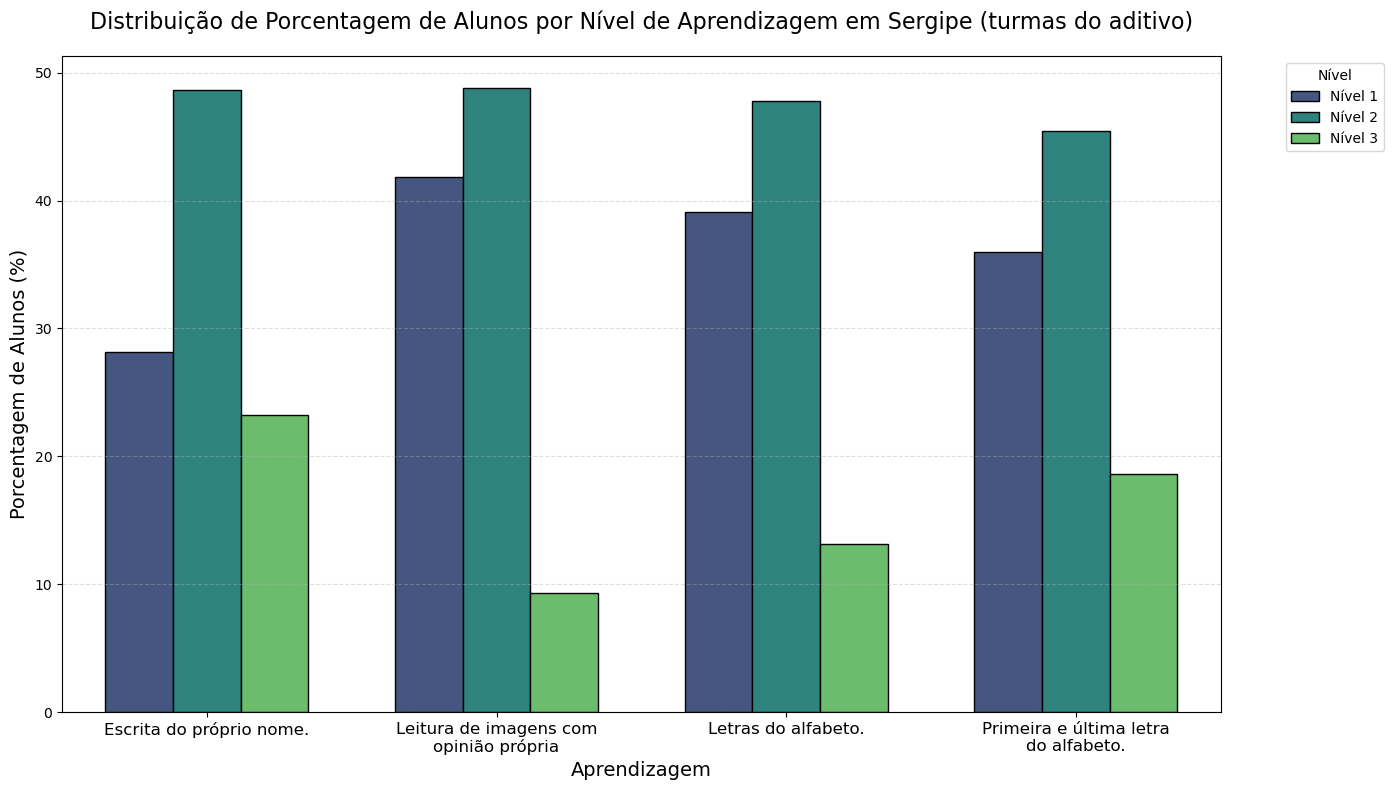

nivel,Nível 1,Nível 2,Nível 3
aprendizagem,,,
Escrita do próprio nome.,28.118393,48.625793,23.255814
Leitura de imagens com opinião própria,41.860465,48.837209,9.302326
Letras do alfabeto.,39.112051,47.780127,13.107822
Primeira e última letra do alfabeto.,35.940803,45.454545,18.604651


In [6]:
# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA']

# Agrupando dados de nível e prática de linguagem
df_analise_diag_geral = df_registros_diag.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
df_analise_diag_geral['total'] = df_analise_diag_geral[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)

# Agrupando dados de nível em porcentagem
porcentagem_diag_nivel_estado = df_analise_diag_geral[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise_diag_geral['total'], axis=0) * 100


# Criando gráfico de barras para análise geral da avaliação diagnóstica
# Criando diretório para salvar os gráficos
output_dir = "Data_files/graficos_diagnostica_turmas_aditivo"
os.makedirs(output_dir, exist_ok=True)

# 1. Preparar os dados (formato long)
df_long = porcentagem_diag_nivel_estado.reset_index().melt(
    id_vars='aprendizagem', 
    var_name='nivel', 
    value_name='contagem'
)

# 2. Definir quais rótulos serão quebrados em duas linhas
rotulos_quebrados = []
for rotulo in porcentagem_diag_nivel_estado.index:
    if rotulo == "Leitura de imagens com opinião própria":
        rotulo = "Leitura de imagens com\nopinião própria"
    elif rotulo == "Primeira e última letra do alfabeto.":
        rotulo = "Primeira e última letra\ndo alfabeto."
    rotulos_quebrados.append(rotulo)

# 3. Configurar o gráfico
plt.figure(figsize=(14, 8))  # Aumentei a altura para acomodar as quebras
ax = sns.barplot(
    data=df_long,
    x='aprendizagem',
    y='contagem',
    hue='nivel',
    palette='viridis',
    edgecolor='black',
    width=0.7  # Barras um pouco mais estreitas
)

# 4. Ajustar os rótulos do eixo X
ax.set_xticks(range(len(porcentagem_diag_nivel_estado.index)))
ax.set_xticklabels(
    rotulos_quebrados,  # Usa os rótulos modificados
    rotation=0,
    ha='center',
    fontsize=12,
    linespacing=1.2  # Espaçamento entre linhas
)

# 5. Ajustar margens e layout
plt.gcf().subplots_adjust(bottom=0.3)  # Mais espaço na parte inferior
plt.title('Distribuição de Porcentagem de Alunos por Nível de Aprendizagem em Sergipe (turmas do aditivo)', fontsize=16, pad=20)
plt.xlabel('Aprendizagem', fontsize=14)
plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Adicionar grid para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 7. Salvar o gráfico
plt.savefig(os.path.join(output_dir, 'grafico_diagnostica_turmas_aditivo_se.png'), bbox_inches='tight', dpi=300)

# 8. Exibir o gráfico 
plt.tight_layout()
plt.show()
porcentagem_diag_nivel_estado


Observação: 

Gerando informações gerais sobre relatório de turmas

In [7]:
# Tratando dados de relatórios:
mapeamento_respostas = {
    'pergunta_1': {
        'Busca por novo emprego.': 'Busca\npor emprego'
    },
    'pergunta_3': {
        'Apresenta alta motivação e foco no aprendizado.': 'Muito interessado',
        'Demonstra interesse moderado, mas com dificuldades em manter o foco.': 'Interesse moderado',
        'Parcialmente. Realiza algumas atividades, mas ainda necessita de muita ajuda.': 'Parcialmente interessado',
        'Mostra-se desinteressado ou pouco motivado.': 'Desinteressado'
    },
    'pergunta_4': {
        'Parcialmente. Realiza algumas atividades, mas ainda necessita de muita ajuda.': 'Parcialmente',
        'Não. Somente com ajuda.': 'Não',
        'Sim. Alta autonomia, consegue executar as tarefas com pouca ou nenhuma orientação.': 'Sim',
        'Reconhece suas inseguranças, mas tenta superá-las.': 'Reconhece inseguranças',
        'Apresenta alta capacidade de enfrentar as dificuldades e seguir adiante.': 'Alta independência'
    },
    'pergunta_5': {
        'Reconhece suas inseguranças, mas tenta superá-las.': 'Reconhece inseguranças',
        'Demonstra insegurança evidente, evita atividades desafiadoras.': 'Insegurança evidente',
        'Apresenta alta capacidade de enfrentar as dificuldades e seguir adiante.': 'Alta independência',
        'Persiste e busca melhorar, encarando os erros como parte do processo.': 'Busca melhorar',
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Persiste, mas demonstra frustração.': 'Persiste com frustração'
    },
    'pergunta_6': {
        'Persiste e busca melhorar, encarando os erros como parte do processo.': 'Busca melhorar',
        'Persiste, mas demonstra frustração.': 'Persiste com frustração',
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Demonstra insegurança evidente, evita atividades desafiadoras.': 'Insegurança evidente',
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
    },
    'pergunta_7': {
        'Participam ativamente, colaboram e interagem com os colegas': 'Participação ativa',
        'Participam ocasionalmente, mas sem muita iniciativa.': 'Participação ocasional',
        'Dificuldades em algumas áreas.': 'Algumas dificuldades',
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação do aprendizado',
        'Consegue ler e escrever com confiança.': 'Confiança em leitura e escrita'
    },
    'pergunta_8': {
        'Dificuldade significativa em leitura e escrita.': 'Dificuldade significativa',
        'Consegue ler e escrever com confiança.': 'Confiança em leitura e escrita',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação do aprendizado',
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização'
    },
    'pergunta_9': {
        'Dificuldade em aplicar o aprendizado.': 'Dificuldade em aplicar,',
        'Facilidade em aplicar o aprendizado em diferentes contextos do cotidiano.': 'Facilidade de aplicação',
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização',
        'Valoriza parcialmente, mas ainda tem dificuldades em ver utilidade prática.': 'Valoriza parcialmente'
    },
    'pergunta_10': {
        'Alta valorização, percebe o impacto positivo do aprendizado em sua vida.': 'Alta valorização',
        'Valoriza parcialmente, mas ainda tem dificuldades em ver utilidade prática.': 'Valoriza parcialmente'
    }
}

# Aplicar o mapeamento
for pergunta, mapeamento in mapeamento_respostas.items():
    if pergunta in df_relatorios_diagnostica.columns:
        df_relatorios_diagnostica[pergunta] = df_relatorios_diagnostica[pergunta].replace(mapeamento)
        

In [8]:
# Lista de colunas de perguntas (assumindo que são todas as colunas que começam com "pergunta_")
colunas_perguntas = [col for col in df_relatorios_diagnostica.columns if col.startswith('pergunta_')]

# Função para substituir textos que começam com "Outros:" por "Outros"
def substituir_outros(texto):
    if pd.isna(texto):  # Mantém valores nulos como estão
        return texto
    if isinstance(texto, str) and texto.startswith('Outros:'):
        return 'Outros'
    return texto

# Aplicar a função a todas as colunas de perguntas
for col in colunas_perguntas:
    df_relatorios_diagnostica[col] = df_relatorios_diagnostica[col].apply(substituir_outros)

In [9]:
# Dicionário com os títulos descritivos
titulos_perguntas = {
    'pergunta_1': '1. O que os motiva a voltar a estudar?',
    'pergunta_2': '2. Quais as perspectivas das turmas quanto a alfabetização e letramento?',
    'pergunta_3': '3. Quanto ao interesse pelo processo de alfabetização,as turmas:',
    'pergunta_4': '4. As turmas conseguem realizar atividades de forma independente?',
    'pergunta_5': '5. O que as turmas fazem quando não entendem algo?',
    'pergunta_6': '6. Como as turmas reagem diante de erros ou falhas?',
    'pergunta_7': '7. Como as turmas se comportam durante atividades em grupo?',
    'pergunta_8': '8. Quanto a leitura de palavras simples e escrita de sílabas/letra, as turmas:',
    'pergunta_9': '9. Em relação a aplicação do conhecimento em situações práticas, as turmas:',
    'pergunta_10': '10. Como as turmas valorizam o saber no dia a dia?'
}

# Função para quebrar textos longos
def quebrar_texto(texto, max_length=15):
    if pd.isna(texto):
        return texto
    return '\n'.join(textwrap.wrap(str(texto), width=max_length))

# Configurações iniciais
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# 1. Preparação dos dados (igual ao anterior)
analise_perguntas = pd.DataFrame()
for pergunta in [f'pergunta_{i}' for i in range(1, 11)]:
    contagem = df_relatorios_diagnostica[pergunta].value_counts().reset_index()
    contagem.columns = ['resposta', 'contagem']
    contagem['porcentagem'] = (contagem['contagem'] / contagem['contagem'].sum()) * 100
    contagem['pergunta'] = pergunta
    contagem['resposta_formatada'] = contagem['resposta'].apply(quebrar_texto)
    analise_perguntas = pd.concat([analise_perguntas, contagem])

# 2. Gerar e salvar gráficos em arquivos separados
for file_num in range(5):
    fig, axes = plt.subplots(1, 2, figsize=(22, 12))
    plt.subplots_adjust(wspace=0.4, hspace=0.5)
    
    start_idx = file_num * 2
    end_idx = start_idx + 2
    
    for i, pergunta in enumerate([f'pergunta_{j}' for j in range(start_idx+1, end_idx+1)]):
        dados = analise_perguntas[analise_perguntas['pergunta'] == pergunta].sort_values('porcentagem', ascending=False)
        
        # Gráfico Seaborn - REMOVER RÓTULOS DO EIXO X
        ax = sns.barplot(
            data=dados,
            x='resposta_formatada',
            y='porcentagem',
            hue='resposta_formatada',
            palette='viridis',
            dodge=False,
            ax=axes[i],
            legend=False
        )
        
        # Remover rótulos do eixo X
        ax.set_xticklabels([])
        ax.set_xlabel('')
        
        # Títulos e labels
        ax.set_title(titulos_perguntas[pergunta], fontsize=18, pad=25)
        ax.set_ylabel('Porcentagem (%)', fontsize=14)
        
        # Ajustar eixo y
        ax.set_ylim(0, min(100, dados['porcentagem'].max() * 1.2))
        sns.despine(left=True)
        
        # Adicionar valores nas barras
        for p in ax.patches:
            ax.annotate(
                f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=14
            )
        
        # CRIAR LEGENDA NA ÁREA VAZIA
        handles = [plt.Rectangle((0,0),1,1, color=color) for color in sns.color_palette("viridis", len(dados))]
        ax.legend(
            handles=handles,
            labels=list(dados['resposta_formatada']),
            title='Respostas',
            bbox_to_anchor=(0.9, 0.9),  # Posição relativa ao gráfico
            loc='upper left',
            borderaxespad=0.,
            frameon=True,
            fontsize=14,
            title_fontsize=16
        )
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Salvar figura
    output_path = os.path.join(output_dir, f'graficos_relatorio_diag_{file_num+1}.png')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

print(f"✅ Gráficos salvos em: {os.path.abspath(output_dir)}")
analise_perguntas.sort_values(['pergunta', 'porcentagem'], ascending=[True, False])


✅ Gráficos salvos em: /home/fabcmc/GitHub Files/FGV/pba_se_2025/Data_files/graficos_diagnostica_turmas_aditivo


,resposta,contagem,porcentagem,pergunta,resposta_formatada
0,Desejo de aprender.,28,93.333333,pergunta_1,Desejo de\naprender.
1,Busca\npor emprego,1,3.333333,pergunta_1,Busca por\nemprego
2,Outros,1,3.333333,pergunta_1,Outros
0,Alta valorização,17,58.620690,pergunta_10,Alta\nvalorização
1,Valoriza parcialmente,12,41.379310,pergunta_10,Valoriza\nparcialmente
0,Aprender a ler.,22,73.333333,pergunta_2,Aprender a ler.
1,Ter autonomia.,6,20.000000,pergunta_2,Ter autonomia.
2,Outros,1,3.333333,pergunta_2,Outros
3,Melhorar a comunicação.,1,3.333333,pergunta_2,Melhorar a\ncomunicação.
0,Muito interessado,24,80.000000,pergunta_3,Muito\ninteressado


## Estudando os dados por estado
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados no RN;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

### Entendendo alunos e turmas por município

In [10]:
# Criar uma cópia para trabalhar sem modificar o original
df_trabalho = df_cadastro.copy()

# Certificando que 'turma' tem o mesmo tipo em ambos os DataFrames
df_trabalho['turma'] = df_trabalho['turma'].astype(str).str.strip()
df_turmas['turma'] = df_turmas['turma'].astype(str).str.strip()

# Executando o merge
df_trabalho = df_trabalho.merge(
    df_turmas[['turma', 'municipio']], 
    on='turma', 
    how='left'
)

# Contando número de alunos e turmas por município
df_dados_municipios = df_trabalho.groupby('municipio').agg(
    numero_alunos=('nome', 'count'),
    numero_turmas=('turma', 'nunique')
).reset_index()

# Calculando média de alunos por turma por município e entendendo a relevância de cada município perante ao total de alunos enturmados
df_dados_municipios['media_alunos_por_turma'] = df_dados_municipios['numero_alunos'] / df_dados_municipios['numero_turmas']
df_dados_municipios['relevancia'] = df_dados_municipios['numero_alunos'] * 100 / enturmados

# Separando número de alunos por turma em cada município
turmas_e_municipios = df_turmas[['turma', 'municipio']]
turmas_e_municipios = turmas_e_municipios.rename(columns={'qtd._alfabetizandos': 'total_turma'})

# Entendendo quantidade de alunos em cada nível por turma em cada município
contagem_alunos_turma_diag = df_registros_diag.groupby('turma')['nome'].nunique().reset_index()
contagem_diag_turma = df_registros_diag.groupby(['turma', 'aprendizagem', 'nivel']).size().unstack(fill_value=0).reset_index()
contagem_diag_turma['total_turma'] = contagem_diag_turma[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
contagem_diag_turma = contagem_diag_turma.merge(turmas_e_municipios, on='turma', how='left')
contagem_diag_municipio = contagem_diag_turma.groupby(['municipio', 'turma', 'total_turma', 'aprendizagem'])[['Nível 1', 'Nível 2', 'Nível 3']].sum().reset_index()

# Entendendo a realidade dos níveis para cada município usando média ponderada para unificar os dados
#media_diag_nivel_municipio = contagem_diag_municipio.groupby(['municipio', 'aprendizagem']).apply(lambda x: pd.Series({
#    'media_nivel_1': (x['Nível 1'] * x['total_turma']).sum() / x['total_turma'].sum(),
#    'media_nivel_2': (x['Nível 2'] * x['total_turma']).sum() / x['total_turma'].sum(),
#    'media_nivel_3': (x['Nível 3'] * x['total_turma']).sum() / x['total_turma'].sum()
#    })).reset_index() # Peso da média ponderada é a quantidade de alunos por turma

# Imprimindo as primeiras linhas do DataFrame resultante
#print(media_diag_nivel_municipio.head())
#contagem_alunos_turma_diag.head()
#teste = turmas_e_municipios.groupby('municipio')['total_turma'].sum().reset_index()
#teste[teste['municipio'] == 'NOSSA SENHORA DO SOCORRO']
contagem_diag_municipio['municipio'].unique()


/tmp/ipykernel_64080/4139845977.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagem_diag_turma = df_registros_diag.groupby(['turma', 'aprendizagem', 'nivel']).size().unstack(fill_value=0).reset_index()


array(['ARACAJU', 'CANINDÉ DE SÃO FRANCISCO', 'CAPELA', 'CARIRA',
       'ITABAIANA', 'ITABAIANINHA', 'NOSSA SENHORA DO SOCORRO',
       'PORTO DA FOLHA', 'POÇO REDONDO', 'SALGADO', 'SIMÃO DIAS',
       'SÃO CRISTÓVÃO'], dtype=object)

Agora vamos classificar os municipios de acordo com as médias em nível 3 em ordem decrescente e entender quais municipios apresentam maiores valores de nível 3. Nosso objetivo é tentar entender se há um padrão geográfico.

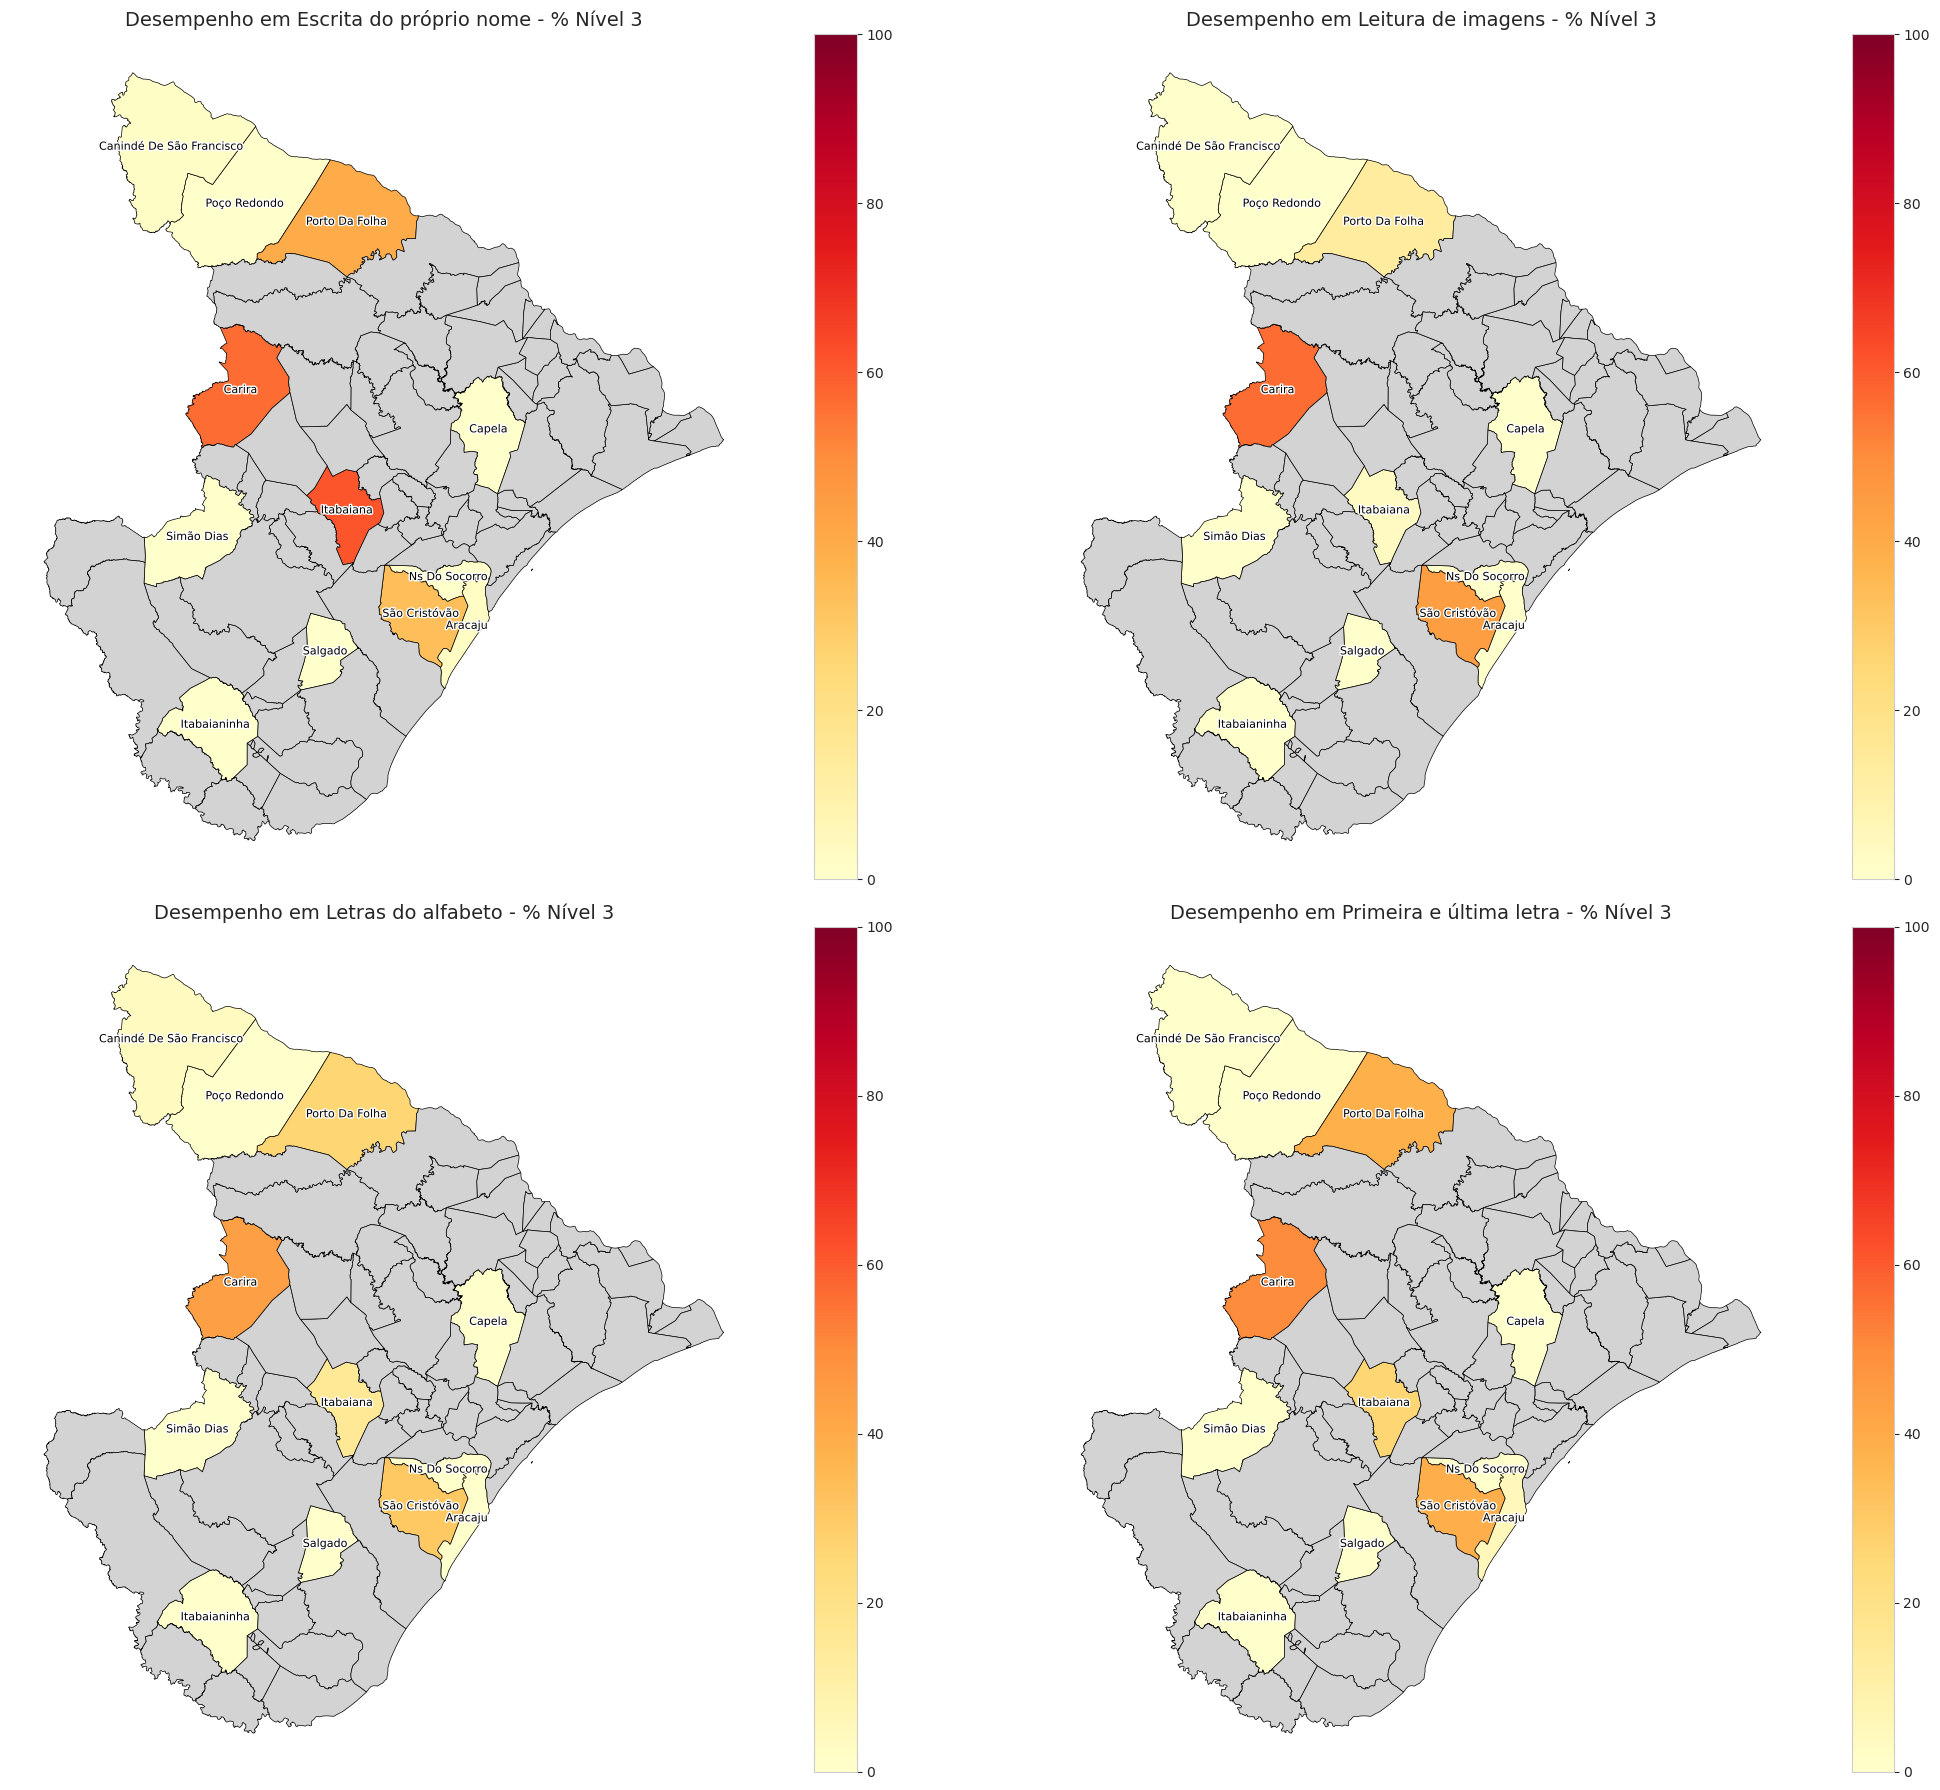

Mapas gerados com sucesso!


In [11]:
# 1. Função para padronizar nomes de municípios (melhorada)
def padronizar_nomes(texto):
    return (
        texto.str.upper()
        .str.normalize('NFKD')
        .str.encode('ascii', errors='ignore')
        .str.decode('utf-8')
        .str.replace(r"\b(DE|DA|DO|DAS|DOS)\b", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# 2. Função para abreviar nomes (expandida)
def abreviar_nome(nome):
    substituicoes = {
        "NOSSA SENHORA": "NS",
        "N.S.": "NS",
        "TOBIAS BARRETO": "T. BARRETO",
        "RIACHÃO DO DANTAS": "R. DANTAS",
        "SANTA LUZIA DO ITANHY": "STª LUZIA ITANHY",
        "SAO FRANCISCO": "S. FRANCISCO"
    }
    nome = nome.upper()
    for original, abreviado in substituicoes.items():
        nome = nome.replace(original, abreviado)
    return nome.title()

# 3. Cálculo das porcentagens (versão robusta)
def calcular_porcentagens(df):
    return (
        df.groupby(['municipio', 'aprendizagem'], as_index=False)
        .agg({
            'Nível 1': 'sum',
            'Nível 2': 'sum',
            'Nível 3': 'sum',
            'total_turma': 'sum'
        })
        .assign(
            porcentagem_nivel_1=lambda x: (x['Nível 1'] * 100) / x['total_turma'],
            porcentagem_nivel_2=lambda x: (x['Nível 2'] * 100) / x['total_turma'],
            porcentagem_nivel_3=lambda x: (x['Nível 3'] * 100) / x['total_turma']
        )
        .drop(['Nível 1', 'Nível 2', 'Nível 3', 'total_turma'], axis=1)
    )

# 4. Carregar e preparar shapefile (com tratamento de erro)
def carregar_shapefile():
    try:
        sergipe = gpd.read_file('Data_files/SE_Municipios_2024/SE_Municipios_2024.shp')
        sergipe['NM_MUN_PADRONIZADO'] = padronizar_nomes(sergipe['NM_MUN'])
        return sergipe
    except Exception as e:
        print(f"Erro ao carregar shapefile: {e}")
        return None

# 5. Processamento principal
def gerar_mapas(contagem_diag_municipio):
    # Calcular porcentagens
    porcentagens = calcular_porcentagens(contagem_diag_municipio)
    
    # Classificar por aprendizagem
    aprendizagens = {
        'Escrita do próprio nome.': 'Escrita do próprio nome',
        'Leitura de imagens com opinião própria': 'Leitura de imagens',
        'Letras do alfabeto.': 'Letras do alfabeto',
        'Primeira e última letra do alfabeto.': 'Primeira e última letra'
    }
    
    dfs = {
        nome: porcentagens[porcentagens['aprendizagem'] == chave]
        .sort_values('porcentagem_nivel_3', ascending=False)
        for chave, nome in aprendizagens.items()
    }
    
    # Carregar shapefile
    sergipe = carregar_shapefile()
    if sergipe is None:
        print("Não foi possível continuar sem o shapefile")
        return
    
    # Preparar plots
    fig, axes = plt.subplots(2, 2, figsize=(22, 18))
    axes = axes.flatten()
    
    for ax, (titulo, df) in zip(axes, dfs.items()):
        try:
            # Padronizar nomes no DataFrame atual
            df = df.copy()
            df['municipio_padronizado'] = padronizar_nomes(df['municipio'])
            
            # Mesclar com shapefile
            merged = sergipe.merge(
                df,
                left_on='NM_MUN_PADRONIZADO',
                right_on='municipio_padronizado',
                how='left'
            )
            
            # Plotar sem basemap (evita problemas com PROJ)
            merged.plot(
                column='porcentagem_nivel_3',
                cmap='YlOrRd',
                legend=True,
                ax=ax,
                edgecolor='black',
                linewidth=0.5,
                missing_kwds={'color': 'lightgrey'},
                vmin=0,
                vmax=100
            )
            
            # Adicionar rótulos
            for idx, row in merged.iterrows():
                if not pd.isna(row['porcentagem_nivel_3']):
                    nome = abreviar_nome(row['NM_MUN'])
                    ax.annotate(
                        text=nome,
                        xy=row['geometry'].centroid.coords[0],
                        ha='center',
                        va='center',
                        fontsize=8,
                        color='black',
                        path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
                    )
            
            ax.set_title(f'Desempenho em {titulo} - % Nível 3', fontsize=14)
            ax.set_axis_off()
            
        except Exception as e:
            print(f"Erro ao processar {titulo}: {str(e)}")
            ax.set_title(f"Erro: {titulo}", color='red')
            continue
    
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, 'heatmaps_se_turmas_aditivo_diag.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()
    print("Mapas gerados com sucesso!")

# Execução principal
if __name__ == "__main__":
    # Certifique-se que contagem_diag_municipio está carregado
    if 'contagem_diag_municipio' in locals() or 'contagem_diag_municipio' in globals():
        gerar_mapas(contagem_diag_municipio)
    else:
        print("DataFrame 'contagem_diag_municipio' não encontrado")

A partir desses resultados, vamos gerar os gráficos por município e entender a variabilidade dos dados através da barra de erro.

### Criando gráficos e exportando para relatórios

In [12]:
# Lista de municípios únicos
municipios = df_registros_diag['municipio'].unique()


# Criando loop para gerar gráficos
for municipio in municipios:
    # Filtrar dados para o município atual
    df_municipio = df_registros_diag[df_registros_diag['municipio'] == municipio]
    
    # Agrupar dados (igual ao seu processamento original)
    df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
    df_analise['total'] = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].sum(axis=1)
    
    # Agrupado dados em porcentagem
    porcentagem_nivel = df_analise[['Nível 1', 'Nível 2', 'Nível 3']].div(df_analise['total'], axis=0) * 100    
    
    # Preparar dados no formato longo
    df_long = porcentagem_nivel.reset_index().melt(
        id_vars='aprendizagem',
        var_name='nivel',
        value_name='contagem'
    )
    
    # Quebra de rótulos específicos (igual ao anterior)
    rotulos_quebrados = []
    for rotulo in porcentagem_nivel.index:
        if rotulo == "Leitura de imagens com opinião própria":
            rotulo = "Leitura de imagens com\nopinião própria"
        elif rotulo == "Primeira e última letra do alfabeto":
            rotulo = "Primeira e última letra\ndo alfabeto."
        rotulos_quebrados.append(rotulo)
    
    # Criar figura
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=df_long,
        x='aprendizagem',
        y='contagem',
        hue='nivel',
        palette='viridis',
        edgecolor='black',
        width=0.7
    )
    
    # Formatação do gráfico
    ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)
    plt.title(f'Distribuição por Nível de Aprendizagem\nMunicípio: {municipio}', fontsize=16, pad=20)
    plt.xlabel('Aprendizagem', fontsize=14)
    plt.ylabel('Porcentagem de Alunos (%)', fontsize=14)
    plt.legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    # Salvar o gráfico
    nome_arquivo = f'grafico_diagnostica_aditivo_{municipio.lower().replace(" ", "_")}.png'
    caminho_completo = os.path.join(output_dir, nome_arquivo)
    
    plt.savefig(
        caminho_completo,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )
    
    plt.close()  # Fecha a figura para liberar memória
    
    print(f'Gráfico salvo: {caminho_completo}')

print("Processo concluído! Todos os gráficos foram gerados.")


/tmp/ipykernel_64080/1412770168.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_64080/1412770168.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica_turmas_aditivo/grafico_diagnostica_aditivo_itabaiana.png


/tmp/ipykernel_64080/1412770168.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_64080/1412770168.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica_turmas_aditivo/grafico_diagnostica_aditivo_são_cristóvão.png


/tmp/ipykernel_64080/1412770168.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_64080/1412770168.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


...

Gráfico salvo: Data_files/graficos_diagnostica_turmas_aditivo/grafico_diagnostica_aditivo_poço_redondo.png


/tmp/ipykernel_64080/1412770168.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_64080/1412770168.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica_turmas_aditivo/grafico_diagnostica_aditivo_carira.png


/tmp/ipykernel_64080/1412770168.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise = df_municipio.groupby(['aprendizagem', 'nivel']).size().unstack(fill_value=0)
/tmp/ipykernel_64080/1412770168.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rotulos_quebrados, rotation=0, ha='center', fontsize=12, linespacing=1.2)


Gráfico salvo: Data_files/graficos_diagnostica_turmas_aditivo/grafico_diagnostica_aditivo_capela.png
Processo concluído! Todos os gráficos foram gerados.


In [13]:
# 1. Cálculo das porcentagens (corrigido para evitar warning)
def calcular_porcentagens(df):
    resultados = []
    for (municipio, aprendizagem), group in df.groupby(['municipio', 'aprendizagem']):
        total_turma = group['total_turma'].sum()
        if total_turma > 0:
            resultados.append({
                'municipio': municipio,
                'aprendizagem': aprendizagem,
                'porcentagem_nivel_1': (group['Nível 1'].sum() * 100) / total_turma,
                'porcentagem_nivel_2': (group['Nível 2'].sum() * 100) / total_turma,
                'porcentagem_nivel_3': (group['Nível 3'].sum() * 100) / total_turma
            })
    return pd.DataFrame(resultados)

porcentagem_diag_nivel_municipio = calcular_porcentagens(contagem_diag_municipio)
porcentagem_diag_nivel_municipio

,municipio,aprendizagem,porcentagem_nivel_1,porcentagem_nivel_2,porcentagem_nivel_3
0,ARACAJU,Escrita do próprio nome.,8.108108,89.189189,2.702703
1,ARACAJU,Leitura de imagens com opinião própria,40.540541,59.459459,0.000000
2,ARACAJU,Letras do alfabeto.,13.513514,86.486486,0.000000
3,ARACAJU,Primeira e última letra do alfabeto.,16.216216,78.378378,5.405405
4,CANINDÉ DE SÃO FRANCISCO,Escrita do próprio nome.,30.188679,67.924528,1.886792
5,CANINDÉ DE SÃO FRANCISCO,Leitura de imagens com opinião própria,54.716981,45.283019,0.000000
6,CANINDÉ DE SÃO FRANCISCO,Letras do alfabeto.,45.283019,50.943396,3.773585
7,CANINDÉ DE SÃO FRANCISCO,Primeira e última letra do alfabeto.,50.943396,49.056604,0.000000
8,CAPELA,Escrita do próprio nome.,57.142857,42.857143,0.000000
9,CAPELA,Leitura de imagens com opinião própria,57.142857,42.857143,0.000000


In [14]:
porcentagem_diag_nivel_municipio.to_excel('Data_files/porcentagem_diag_nivel_municipio.xlsx', index=False)
